# TensorFlow LSTM (Many-to-One) with Daily Bitcoin Return Target

This notebook builds a **many-to-one LSTM** that predicts the **next daily Bitcoin log return**:

```text
r_t = log(P_t / P_{t-1})
```

where `P_t` is the daily close price.

Features are constructed from the 5-minute source data and aggregated to daily frequency:
- `daily_log_return`
- `daily_volatility` (intraday 5-minute return standard deviation per day)
- `volatility_7d` (7-day rolling average of `daily_volatility`)

It uses:
- chronological **train / validation / test** split
- **walk-forward validation** with a rolling **30-day training window**
- ~50 hyperparameter combinations in grid search
- checkpointing so the best model is always saved, even if training is interrupted.



In [1]:
from __future__ import annotations

import atexit
import importlib.util
import json
import random
import shutil
import socket
import subprocess
import sys
import time
from itertools import product
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

print('TensorFlow:', tf.__version__)


I0000 00:00:1780252722.825624 3364889 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780252723.515349 3364889 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780252738.453822 3364889 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0


In [2]:
# Paths and core configuration
DATA_PATH = Path('data/BTC/BTC_USD_coinbase_spot_5min.csv')
ARTIFACTS_DIR = Path('artifacts/lstm_walk_forward')
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

TIMESTAMP_COL = 'timestamp_utc'
TARGET_COL = 'target_next_daily_log_return'
FEATURE_COLS = ['daily_log_return', 'daily_volatility', 'volatility_7d']

TRAIN_WINDOW_DAYS = 30
VAL_PERIOD_DAYS = 30
TEST_PERIOD_DAYS = 30
FOLD_STEP_DAYS = 3
FOLD_HORIZON_DAYS = 3

MAX_EPOCHS = 25
PATIENCE = 4
GRID_LIMIT = 50
SEED = 42

USE_CUDA_IF_AVAILABLE = True
REQUIRE_CUDA = True
ENABLE_XLA = True
ENABLE_MIXED_PRECISION = True

AUTO_START_TENSORBOARD = True
TENSORBOARD_HOST = '127.0.0.1'
TENSORBOARD_PORT = 6006
TENSORBOARD_ROOT_LOGDIR = ARTIFACTS_DIR / 'tensorboard'
TENSORBOARD_ROOT_LOGDIR.mkdir(parents=True, exist_ok=True)
TENSORBOARD_PROCESS: subprocess.Popen | None = None
HAS_TENSORBOARD = importlib.util.find_spec('tensorboard') is not None
TENSORBOARD_WARNING_EMITTED = False

if not HAS_TENSORBOARD:
    AUTO_START_TENSORBOARD = False
    print('TensorBoard package is missing. Install with: uv pip install tensorboard')


def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)


def configure_runtime_for_speed(
    use_cuda_if_available: bool = USE_CUDA_IF_AVAILABLE,
    require_cuda: bool = REQUIRE_CUDA,
    enable_xla: bool = ENABLE_XLA,
    enable_mixed_precision: bool = ENABLE_MIXED_PRECISION,
) -> list[tf.config.PhysicalDevice]:
    if enable_xla:
        tf.config.optimizer.set_jit(True)

    gpus = tf.config.list_physical_devices('GPU')

    if use_cuda_if_available and gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)

        if enable_mixed_precision:
            tf.keras.mixed_precision.set_global_policy('mixed_float16')
    else:
        tf.keras.mixed_precision.set_global_policy('float32')

    if require_cuda and not gpus:
        raise RuntimeError(
            'CUDA GPU was required but not detected. '
            'Launch from WSL with: bash scripts/wsl_jupyter.sh and use kernel Python (LSTM WSL GPU)'
        )

    print('Detected GPUs:', gpus)
    print('XLA enabled:', enable_xla)
    print('Mixed precision policy:', tf.keras.mixed_precision.global_policy())
    return gpus


set_seed(SEED)
GPUS = configure_runtime_for_speed()



Detected GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
XLA enabled: True
Mixed precision policy: <DTypePolicy "mixed_float16">


In [3]:
# Load 5-minute data and build daily target/features
raw = pd.read_csv(DATA_PATH)
raw[TIMESTAMP_COL] = pd.to_datetime(raw[TIMESTAMP_COL], utc=True)
raw = raw.sort_values(TIMESTAMP_COL).reset_index(drop=True)

raw['log_close_5m'] = np.log(raw['close'])
raw['log_return_5m'] = raw['log_close_5m'].diff()

daily = raw.set_index(TIMESTAMP_COL).resample('1D').agg(close=('close', 'last'))
daily_intraday_vol = raw.set_index(TIMESTAMP_COL)['log_return_5m'].resample('1D').std().rename('daily_volatility')

daily = daily.join(daily_intraday_vol)
daily['daily_log_return'] = np.log(daily['close'] / daily['close'].shift(1))
daily['volatility_7d'] = daily['daily_volatility'].rolling(7).mean()
daily[TARGET_COL] = daily['daily_log_return'].shift(-1)

df = daily.reset_index()[[TIMESTAMP_COL, *FEATURE_COLS, TARGET_COL]].dropna().reset_index(drop=True)

max_time = df[TIMESTAMP_COL].max()
test_start = max_time - pd.Timedelta(days=TEST_PERIOD_DAYS)
val_start = test_start - pd.Timedelta(days=VAL_PERIOD_DAYS)

split_masks = {
    'train': df[TIMESTAMP_COL] < val_start,
    'validation': (df[TIMESTAMP_COL] >= val_start) & (df[TIMESTAMP_COL] < test_start),
    'test': df[TIMESTAMP_COL] >= test_start,
}

split_summary = pd.DataFrame(
    {
        name: {
            'rows': int(mask.sum()),
            'start': df.loc[mask, TIMESTAMP_COL].min(),
            'end': df.loc[mask, TIMESTAMP_COL].max(),
        }
        for name, mask in split_masks.items()
    }
).T

print('Prepared daily rows:', len(df))
print('Target:', 'r_t = log(P_t / P_{t-1}), predicted one day ahead via shift(-1)')
print('Validation starts:', val_start)
print('Test starts:', test_start)
display(split_summary)



Prepared daily rows: 3646
Target: r_t = log(P_t / P_{t-1}), predicted one day ahead via shift(-1)
Validation starts: 2026-02-11 00:00:00+00:00
Test starts: 2026-03-13 00:00:00+00:00


,rows,start,end
train,3585,2016-04-19 00:00:00+00:00,2026-02-10 00:00:00+00:00
validation,30,2026-02-11 00:00:00+00:00,2026-03-12 00:00:00+00:00
test,31,2026-03-13 00:00:00+00:00,2026-04-12 00:00:00+00:00


In [4]:
def make_sequences(features: np.ndarray, targets: np.ndarray, seq_len: int) -> tuple[np.ndarray, np.ndarray]:
    x_list: list[np.ndarray] = []
    y_list: list[float] = []

    for idx in range(seq_len, len(features)):
        x_list.append(features[idx - seq_len:idx])
        y_list.append(targets[idx])

    if not x_list:
        return (
            np.empty((0, seq_len, features.shape[1]), dtype=np.float32),
            np.empty((0,), dtype=np.float32),
        )

    return np.asarray(x_list, dtype=np.float32), np.asarray(y_list, dtype=np.float32)


def build_walk_forward_folds(
    data: pd.DataFrame,
    start_time: pd.Timestamp,
    end_time: pd.Timestamp,
    train_window_days: int,
    step_days: int,
    horizon_days: int,
) -> list[dict]:
    folds: list[dict] = []
    fold_id = 0
    cursor = start_time

    while cursor < end_time:
        eval_start = cursor
        eval_end = min(eval_start + pd.Timedelta(days=horizon_days), end_time)
        train_end = eval_start
        train_start = train_end - pd.Timedelta(days=train_window_days)

        train_rows = data[(data[TIMESTAMP_COL] >= train_start) & (data[TIMESTAMP_COL] < train_end)]
        eval_rows = data[(data[TIMESTAMP_COL] >= eval_start) & (data[TIMESTAMP_COL] < eval_end)]

        if len(train_rows) > 0 and len(eval_rows) > 0:
            folds.append(
                {
                    'fold_id': fold_id,
                    'train_start': train_start,
                    'train_end': train_end,
                    'eval_start': eval_start,
                    'eval_end': eval_end,
                }
            )
            fold_id += 1

        cursor = cursor + pd.Timedelta(days=step_days)

    return folds


def describe_folds(name: str, folds: list[dict]) -> None:
    fold_df = pd.DataFrame(folds)
    print(f'{name} folds: {len(folds)}')
    if not fold_df.empty:
        display(fold_df.head())


val_folds = build_walk_forward_folds(
    data=df,
    start_time=val_start,
    end_time=test_start,
    train_window_days=TRAIN_WINDOW_DAYS,
    step_days=FOLD_STEP_DAYS,
    horizon_days=FOLD_HORIZON_DAYS,
)

test_folds = build_walk_forward_folds(
    data=df,
    start_time=test_start,
    end_time=max_time,
    train_window_days=TRAIN_WINDOW_DAYS,
    step_days=FOLD_STEP_DAYS,
    horizon_days=FOLD_HORIZON_DAYS,
)

describe_folds('Validation', val_folds)
describe_folds('Test', test_folds)


Validation folds: 10


,fold_id,train_start,train_end,eval_start,eval_end
0,0,2026-01-12 00:00:00+00:00,2026-02-11 00:00:00+00:00,2026-02-11 00:00:00+00:00,2026-02-14 00:00:00+00:00
1,1,2026-01-15 00:00:00+00:00,2026-02-14 00:00:00+00:00,2026-02-14 00:00:00+00:00,2026-02-17 00:00:00+00:00
2,2,2026-01-18 00:00:00+00:00,2026-02-17 00:00:00+00:00,2026-02-17 00:00:00+00:00,2026-02-20 00:00:00+00:00
3,3,2026-01-21 00:00:00+00:00,2026-02-20 00:00:00+00:00,2026-02-20 00:00:00+00:00,2026-02-23 00:00:00+00:00
4,4,2026-01-24 00:00:00+00:00,2026-02-23 00:00:00+00:00,2026-02-23 00:00:00+00:00,2026-02-26 00:00:00+00:00


Test folds: 10


,fold_id,train_start,train_end,eval_start,eval_end
0,0,2026-02-11 00:00:00+00:00,2026-03-13 00:00:00+00:00,2026-03-13 00:00:00+00:00,2026-03-16 00:00:00+00:00
1,1,2026-02-14 00:00:00+00:00,2026-03-16 00:00:00+00:00,2026-03-16 00:00:00+00:00,2026-03-19 00:00:00+00:00
2,2,2026-02-17 00:00:00+00:00,2026-03-19 00:00:00+00:00,2026-03-19 00:00:00+00:00,2026-03-22 00:00:00+00:00
3,3,2026-02-20 00:00:00+00:00,2026-03-22 00:00:00+00:00,2026-03-22 00:00:00+00:00,2026-03-25 00:00:00+00:00
4,4,2026-02-23 00:00:00+00:00,2026-03-25 00:00:00+00:00,2026-03-25 00:00:00+00:00,2026-03-28 00:00:00+00:00


In [5]:
def build_model(seq_len: int, n_features: int, lstm_units: int, dropout: float, learning_rate: float) -> tf.keras.Model:
    layers: list[tf.keras.layers.Layer] = [
        tf.keras.layers.Input(shape=(seq_len, n_features)),
        # Keep recurrent_dropout=0 for fast cuDNN GPU kernels when CUDA is available.
        tf.keras.layers.LSTM(lstm_units, recurrent_dropout=0.0),
    ]

    if dropout > 0.0:
        layers.append(tf.keras.layers.Dropout(dropout))

    layers.extend([
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(1, dtype='float32'),
    ])

    model = tf.keras.Sequential(layers)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=[tf.keras.metrics.MeanAbsoluteError(name='mae')],
    )
    return model


def prepare_fold_data(data: pd.DataFrame, fold: dict, seq_len: int) -> dict | None:
    train_df = data[(data[TIMESTAMP_COL] >= fold['train_start']) & (data[TIMESTAMP_COL] < fold['train_end'])].copy()
    eval_df = data[(data[TIMESTAMP_COL] >= fold['eval_start']) & (data[TIMESTAMP_COL] < fold['eval_end'])].copy()

    if len(train_df) <= seq_len + 10 or len(eval_df) == 0:
        return None

    scaler = StandardScaler()
    train_features = scaler.fit_transform(train_df[FEATURE_COLS])
    eval_features = scaler.transform(eval_df[FEATURE_COLS])

    train_targets = train_df[TARGET_COL].to_numpy(dtype=np.float32)
    eval_targets = eval_df[TARGET_COL].to_numpy(dtype=np.float32)

    x_all, y_all = make_sequences(train_features, train_targets, seq_len)
    if len(x_all) < 12:
        return None

    split_idx = int(len(x_all) * 0.8)
    if split_idx <= 0 or split_idx >= len(x_all):
        return None

    x_train = x_all[:split_idx]
    y_train = y_all[:split_idx]
    x_val = x_all[split_idx:]
    y_val = y_all[split_idx:]

    combined_features = np.vstack([train_features, eval_features])
    combined_targets = np.concatenate([train_targets, eval_targets])

    x_eval_list: list[np.ndarray] = []
    y_eval_list: list[float] = []

    eval_start_idx = len(train_df)
    for idx in range(eval_start_idx, len(combined_features)):
        start = idx - seq_len
        if start < 0:
            continue
        x_eval_list.append(combined_features[start:idx])
        y_eval_list.append(float(combined_targets[idx]))

    if not x_eval_list:
        return None

    x_eval = np.asarray(x_eval_list, dtype=np.float32)
    y_eval = np.asarray(y_eval_list, dtype=np.float32)

    return {
        'x_train': x_train,
        'y_train': y_train,
        'x_val': x_val,
        'y_val': y_val,
        'x_eval': x_eval,
        'y_eval': y_eval,
        'eval_timestamps': eval_df[TIMESTAMP_COL].to_numpy(),
    }


def is_port_open(host: str, port: int) -> bool:
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as sock:
        sock.settimeout(0.2)
        return sock.connect_ex((host, port)) == 0


def ensure_tensorboard_running(log_dir: Path) -> str | None:
    global TENSORBOARD_PROCESS

    if not HAS_TENSORBOARD:
        return None

    if not AUTO_START_TENSORBOARD:
        return None

    log_dir.mkdir(parents=True, exist_ok=True)
    url = f'http://{TENSORBOARD_HOST}:{TENSORBOARD_PORT}'

    if is_port_open(TENSORBOARD_HOST, TENSORBOARD_PORT):
        return url

    # Restart stale process handle if it exists.
    if TENSORBOARD_PROCESS is not None and TENSORBOARD_PROCESS.poll() is not None:
        TENSORBOARD_PROCESS = None

    if TENSORBOARD_PROCESS is None:
        cmd = [
            sys.executable,
            '-m',
            'tensorboard.main',
            '--logdir',
            str(log_dir),
            '--host',
            TENSORBOARD_HOST,
            '--port',
            str(TENSORBOARD_PORT),
            '--reload_interval',
            '5',
        ]
        TENSORBOARD_PROCESS = subprocess.Popen(
            cmd,
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL,
        )

    for _ in range(20):
        if is_port_open(TENSORBOARD_HOST, TENSORBOARD_PORT):
            print(f'TensorBoard started: {url} (logdir={log_dir})')
            return url
        time.sleep(0.25)

    print(f'TensorBoard process launched but port {TENSORBOARD_PORT} is not ready yet.')
    return url


def stop_tensorboard() -> None:
    global TENSORBOARD_PROCESS
    if TENSORBOARD_PROCESS is None:
        return

    if TENSORBOARD_PROCESS.poll() is None:
        TENSORBOARD_PROCESS.terminate()
    TENSORBOARD_PROCESS = None


atexit.register(stop_tensorboard)


def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    return {'rmse': rmse, 'mae': mae}


def train_one_fold(
    data: pd.DataFrame,
    fold: dict,
    params: dict,
    combo_dir: Path,
    fold_set_name: str,
) -> dict | None:
    fold_data = prepare_fold_data(data, fold, seq_len=params['seq_len'])
    if fold_data is None:
        return None

    fold_dir = combo_dir / fold_set_name / f"fold_{fold['fold_id']:03d}"
    fold_dir.mkdir(parents=True, exist_ok=True)

    checkpoint_path = fold_dir / 'best_model.keras'
    backup_dir = fold_dir / 'backup'
    tensorboard_log_dir = TENSORBOARD_ROOT_LOGDIR / fold_set_name / combo_dir.name / f"fold_{fold['fold_id']:03d}"
    tensorboard_url = ensure_tensorboard_running(TENSORBOARD_ROOT_LOGDIR)

    model = build_model(
        seq_len=params['seq_len'],
        n_features=len(FEATURE_COLS),
        lstm_units=params['lstm_units'],
        dropout=params['dropout'],
        learning_rate=params['learning_rate'],
    )

    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=str(checkpoint_path),
            monitor='val_loss',
            save_best_only=True,
            verbose=0,
        ),
        tf.keras.callbacks.BackupAndRestore(
            backup_dir=str(backup_dir),
            delete_checkpoint=False,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=PATIENCE,
            restore_best_weights=True,
        ),
    ]

    global TENSORBOARD_WARNING_EMITTED
    if HAS_TENSORBOARD:
        callbacks.insert(
            2,
            tf.keras.callbacks.TensorBoard(
                log_dir=str(tensorboard_log_dir),
                histogram_freq=0,
                write_graph=True,
                update_freq='epoch',
                profile_batch=0,
            ),
        )
    elif not TENSORBOARD_WARNING_EMITTED:
        print('TensorBoard callback disabled because the tensorboard package is not installed.')
        TENSORBOARD_WARNING_EMITTED = True

    history = model.fit(
        fold_data['x_train'],
        fold_data['y_train'],
        validation_data=(fold_data['x_val'], fold_data['y_val']),
        epochs=MAX_EPOCHS,
        batch_size=params['batch_size'],
        shuffle=False,
        verbose=0,
        callbacks=callbacks,
    )

    best_model = tf.keras.models.load_model(checkpoint_path) if checkpoint_path.exists() else model
    y_pred = best_model.predict(fold_data['x_eval'], verbose=0).reshape(-1)

    metrics = regression_metrics(fold_data['y_eval'], y_pred)

    pred_df = pd.DataFrame(
        {
            TIMESTAMP_COL: fold_data['eval_timestamps'],
            'y_true': fold_data['y_eval'],
            'y_pred': y_pred,
        }
    )
    pred_path = fold_dir / 'predictions.csv'
    pred_df.to_csv(pred_path, index=False)

    return {
        'fold_id': fold['fold_id'],
        'rmse': metrics['rmse'],
        'mae': metrics['mae'],
        'model_path': str(checkpoint_path),
        'predictions_path': str(pred_path),
        'epochs_ran': len(history.history.get('loss', [])),
        'tensorboard_log_dir': str(tensorboard_log_dir),
        'tensorboard_url': tensorboard_url,
    }


def build_grid(limit: int = GRID_LIMIT, seed: int = SEED) -> list[dict]:
    base_grid = {
        'seq_len': [3, 5, 7, 10, 14],
        'lstm_units': [16, 32],
        'dropout': [0.0, 0.2],
        'learning_rate': [1e-3, 5e-4, 2e-4],
        'batch_size': [8, 16],
    }

    all_combinations = [
        {
            'seq_len': seq_len,
            'lstm_units': lstm_units,
            'dropout': dropout,
            'learning_rate': learning_rate,
            'batch_size': batch_size,
        }
        for seq_len, lstm_units, dropout, learning_rate, batch_size in product(
            base_grid['seq_len'],
            base_grid['lstm_units'],
            base_grid['dropout'],
            base_grid['learning_rate'],
            base_grid['batch_size'],
        )
    ]

    rng = random.Random(seed)
    rng.shuffle(all_combinations)
    return all_combinations[:limit]


def run_grid_search(
    data: pd.DataFrame,
    folds: list[dict],
    grid: list[dict],
    output_dir: Path,
) -> tuple[pd.DataFrame, dict, Path]:
    output_dir.mkdir(parents=True, exist_ok=True)

    results: list[dict] = []
    best_score = float('inf')
    best_params: dict | None = None
    best_model_path = output_dir / 'best_model_overall.keras'

    for idx, params in enumerate(grid, start=1):
        combo_name = f'combo_{idx:03d}'
        combo_dir = output_dir / combo_name
        combo_dir.mkdir(parents=True, exist_ok=True)

        fold_records: list[dict] = []
        for fold in folds:
            fold_result = train_one_fold(
                data=data,
                fold=fold,
                params=params,
                combo_dir=combo_dir,
                fold_set_name='validation',
            )
            if fold_result is not None:
                fold_records.append(fold_result)

        if not fold_records:
            combo_rmse = float('inf')
            combo_mae = float('inf')
            best_fold_model = None
        else:
            combo_rmse = float(np.mean([r['rmse'] for r in fold_records]))
            combo_mae = float(np.mean([r['mae'] for r in fold_records]))
            best_fold_model = min(fold_records, key=lambda x: x['rmse'])['model_path']

        row = {
            'combo_id': combo_name,
            'val_rmse_mean': combo_rmse,
            'val_mae_mean': combo_mae,
            'n_folds_trained': len(fold_records),
            **params,
            'best_fold_model': best_fold_model,
        }
        results.append(row)

        pd.DataFrame(results).sort_values('val_rmse_mean').to_csv(
            output_dir / 'grid_search_results_live.csv',
            index=False,
        )

        if combo_rmse < best_score and best_fold_model is not None:
            best_score = combo_rmse
            best_params = params.copy()
            shutil.copy2(best_fold_model, best_model_path)
            with (output_dir / 'best_model_metadata.json').open('w', encoding='utf-8') as f:
                json.dump(
                    {
                        'best_combo': combo_name,
                        'best_val_rmse_mean': best_score,
                        'best_params': best_params,
                        'source_model': best_fold_model,
                    },
                    f,
                    indent=2,
                )

        print(f"[{idx:03d}/{len(grid):03d}] {combo_name} | mean_val_rmse={combo_rmse:.8f} | folds={len(fold_records)}")

    results_df = pd.DataFrame(results).sort_values('val_rmse_mean').reset_index(drop=True)
    results_df.to_csv(output_dir / 'grid_search_results_final.csv', index=False)

    if best_params is None:
        raise RuntimeError('No model could be trained. Try smaller seq_len or fewer folds.')

    return results_df, best_params, best_model_path



In [6]:
# Run grid search (~50 combinations) on validation folds
val_grid = build_grid(limit=GRID_LIMIT, seed=SEED)
print('Grid combinations:', len(val_grid))

grid_dir = ARTIFACTS_DIR / 'grid_search'
results_df, best_params, best_model_path = run_grid_search(
    data=df,
    folds=val_folds,
    grid=val_grid,
    output_dir=grid_dir,
)

print('Best params:', best_params)
print('Best model saved at:', best_model_path)
display(results_df.head(10))


Grid combinations: 50


I0000 00:00:1780252747.460851 3364889 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21456 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9
E0000 00:00:1780252749.077685 3364889 util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.
I0000 00:00:1780252749.079596 3365058 service.cc:153] XLA service 0x747e1403e210 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780252749.079612 3365058 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4090, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.23.0)
I0000 00:00:1780252749.123280 3365058 cuda_dnn.cc:461] Loaded cuDNN version 92300
I0000 00:00:1780252749.390633 3365058 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the proc

[001/050] combo_001 | mean_val_rmse=0.02688996 | folds=10
[002/050] combo_002 | mean_val_rmse=0.02558153 | folds=10
[003/050] combo_003 | mean_val_rmse=0.02648406 | folds=10
[004/050] combo_004 | mean_val_rmse=0.02392807 | folds=10
[005/050] combo_005 | mean_val_rmse=0.02296550 | folds=10


I0000 00:00:1780252785.965815 3365056 dot_merger.cc:481] Merging Dots in computation: cluster_120__XlaCompiledKernel_true__XlaHasReferenceVars_false__XlaNumConstantArgs_1__XlaNumResourceArgs_10_.6
I0000 00:00:1780252794.339926 3365052 dot_merger.cc:481] Merging Dots in computation: cluster_120__XlaCompiledKernel_true__XlaHasReferenceVars_false__XlaNumConstantArgs_1__XlaNumResourceArgs_10_.6


[006/050] combo_006 | mean_val_rmse=0.02481101 | folds=10


...

I0000 00:00:1780253660.710443 3365031 dot_merger.cc:481] Merging Dots in computation: cluster_3138__XlaCompiledKernel_true__XlaHasReferenceVars_false__XlaNumConstantArgs_1__XlaNumResourceArgs_9_.6
I0000 00:00:1780253663.609662 3365031 dot_merger.cc:481] Merging Dots in computation: cluster_3153__XlaCompiledKernel_true__XlaHasReferenceVars_false__XlaNumConstantArgs_1__XlaNumResourceArgs_9_.6
I0000 00:00:1780253667.114699 3365032 dot_merger.cc:481] Merging Dots in computation: cluster_3170__XlaCompiledKernel_true__XlaHasReferenceVars_false__XlaNumConstantArgs_1__XlaNumResourceArgs_9_.6
I0000 00:00:1780253669.524497 3365047 dot_merger.cc:481] Merging Dots in computation: cluster_3185__XlaCompiledKernel_true__XlaHasReferenceVars_false__XlaNumConstantArgs_1__XlaNumResourceArgs_9_.6
I0000 00:00:1780253674.512016 3365033 dot_merger.cc:481] Merging Dots in computation: cluster_3204__XlaCompiledKernel_true__XlaHasReferenceVars_false__XlaNumConstantArgs_1__XlaNumResourceArgs_9_.6


[049/050] combo_049 | mean_val_rmse=0.03020244 | folds=10


I0000 00:00:1780253679.155351 3365036 dot_merger.cc:481] Merging Dots in computation: cluster_3223__XlaCompiledKernel_true__XlaHasReferenceVars_false__XlaNumConstantArgs_1__XlaNumResourceArgs_9_.6
I0000 00:00:1780253680.867997 3365033 dot_merger.cc:481] Merging Dots in computation: cluster_3223__XlaCompiledKernel_true__XlaHasReferenceVars_false__XlaNumConstantArgs_1__XlaNumResourceArgs_9_.6
I0000 00:00:1780253686.145300 3365031 dot_merger.cc:481] Merging Dots in computation: cluster_3238__XlaCompiledKernel_true__XlaHasReferenceVars_false__XlaNumConstantArgs_1__XlaNumResourceArgs_9_.6
I0000 00:00:1780253687.581702 3365049 dot_merger.cc:481] Merging Dots in computation: cluster_3238__XlaCompiledKernel_true__XlaHasReferenceVars_false__XlaNumConstantArgs_1__XlaNumResourceArgs_9_.6
I0000 00:00:1780253689.854428 3365032 dot_merger.cc:481] Merging Dots in computation: cluster_3253__XlaCompiledKernel_true__XlaHasReferenceVars_false__XlaNumConstantArgs_1__XlaNumResourceArgs_9_.6
I0000 00:00:178

[050/050] combo_050 | mean_val_rmse=0.03510957 | folds=10
Best params: {'seq_len': 10, 'lstm_units': 32, 'dropout': 0.2, 'learning_rate': 0.0005, 'batch_size': 8}
Best model saved at: artifacts/lstm_walk_forward/grid_search/best_model_overall.keras


,combo_id,val_rmse_mean,val_mae_mean,n_folds_trained,seq_len,lstm_units,dropout,learning_rate,batch_size,best_fold_model
0,combo_005,0.022965,0.018994,10,10,32,0.2,0.0005,8,artifacts/lstm_walk_forward/grid_search/combo_...
1,combo_039,0.023238,0.019092,10,7,32,0.0,0.0010,8,artifacts/lstm_walk_forward/grid_search/combo_...
2,combo_004,0.023928,0.020379,10,14,32,0.2,0.0010,8,artifacts/lstm_walk_forward/grid_search/combo_...
3,combo_020,0.024098,0.020754,10,7,32,0.2,0.0005,8,artifacts/lstm_walk_forward/grid_search/combo_...
4,combo_030,0.024185,0.020806,10,10,16,0.2,0.0005,8,artifacts/lstm_walk_forward/grid_search/combo_...
5,combo_031,0.024566,0.020695,10,3,32,0.2,0.0005,16,artifacts/lstm_walk_forward/grid_search/combo_...
6,combo_042,0.024579,0.020717,10,7,16,0.2,0.0010,16,artifacts/lstm_walk_forward/grid_search/combo_...
7,combo_035,0.024784,0.020630,10,7,32,0.2,0.0010,8,artifacts/lstm_walk_forward/grid_search/combo_...
8,combo_006,0.024811,0.020897,10,5,16,0.2,0.0010,8,artifacts/lstm_walk_forward/grid_search/combo_...
9,combo_012,0.025456,0.021246,10,10,16,0.2,0.0010,16,artifacts/lstm_walk_forward/grid_search/combo_...


In [7]:
def evaluate_on_folds(data: pd.DataFrame, folds: list[dict], params: dict, output_dir: Path, fold_set_name: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    output_dir.mkdir(parents=True, exist_ok=True)

    all_fold_metrics: list[dict] = []
    all_preds: list[pd.DataFrame] = []

    for fold in folds:
        fold_result = train_one_fold(
            data=data,
            fold=fold,
            params=params,
            combo_dir=output_dir,
            fold_set_name=fold_set_name,
        )
        if fold_result is None:
            continue

        all_fold_metrics.append(fold_result)
        pred_df = pd.read_csv(fold_result['predictions_path'])
        pred_df['fold_id'] = fold_result['fold_id']
        all_preds.append(pred_df)

    if not all_fold_metrics:
        raise RuntimeError(f'No folds trained for {fold_set_name}')

    metrics_df = pd.DataFrame(all_fold_metrics).sort_values('fold_id').reset_index(drop=True)
    preds_df = pd.concat(all_preds, ignore_index=True)

    metrics_df.to_csv(output_dir / f'{fold_set_name}_fold_metrics.csv', index=False)
    preds_df.to_csv(output_dir / f'{fold_set_name}_predictions.csv', index=False)

    return metrics_df, preds_df


final_dir = ARTIFACTS_DIR / 'final_evaluation'
val_metrics_df, val_preds_df = evaluate_on_folds(df, val_folds, best_params, final_dir, 'validation')
test_metrics_df, test_preds_df = evaluate_on_folds(df, test_folds, best_params, final_dir, 'test')

print('Validation fold metrics (mean):')
display(val_metrics_df[['rmse', 'mae']].mean().to_frame('value'))
print('Test fold metrics (mean):')
display(test_metrics_df[['rmse', 'mae']].mean().to_frame('value'))


I0000 00:00:1780253707.669913 3365036 dot_merger.cc:481] Merging Dots in computation: cluster_3325__XlaCompiledKernel_true__XlaHasReferenceVars_false__XlaNumConstantArgs_0__XlaNumResourceArgs_8_.5
I0000 00:00:1780253713.379658 3365051 dot_merger.cc:481] Merging Dots in computation: cluster_3347__XlaCompiledKernel_true__XlaHasReferenceVars_false__XlaNumConstantArgs_0__XlaNumResourceArgs_8_.5
I0000 00:00:1780253717.663226 3365039 dot_merger.cc:481] Merging Dots in computation: cluster_3361__XlaCompiledKernel_true__XlaHasReferenceVars_false__XlaNumConstantArgs_0__XlaNumResourceArgs_8_.5
I0000 00:00:1780253724.498588 3365047 dot_merger.cc:481] Merging Dots in computation: cluster_3375__XlaCompiledKernel_true__XlaHasReferenceVars_false__XlaNumConstantArgs_0__XlaNumResourceArgs_8_.5
I0000 00:00:1780253729.602212 3365036 dot_merger.cc:481] Merging Dots in computation: cluster_3391__XlaCompiledKernel_true__XlaHasReferenceVars_false__XlaNumConstantArgs_0__XlaNumResourceArgs_8_.5
I0000 00:00:178

Validation fold metrics (mean):


,value
rmse,0.023405
mae,0.020293


Test fold metrics (mean):


,value
rmse,0.020967
mae,0.017668


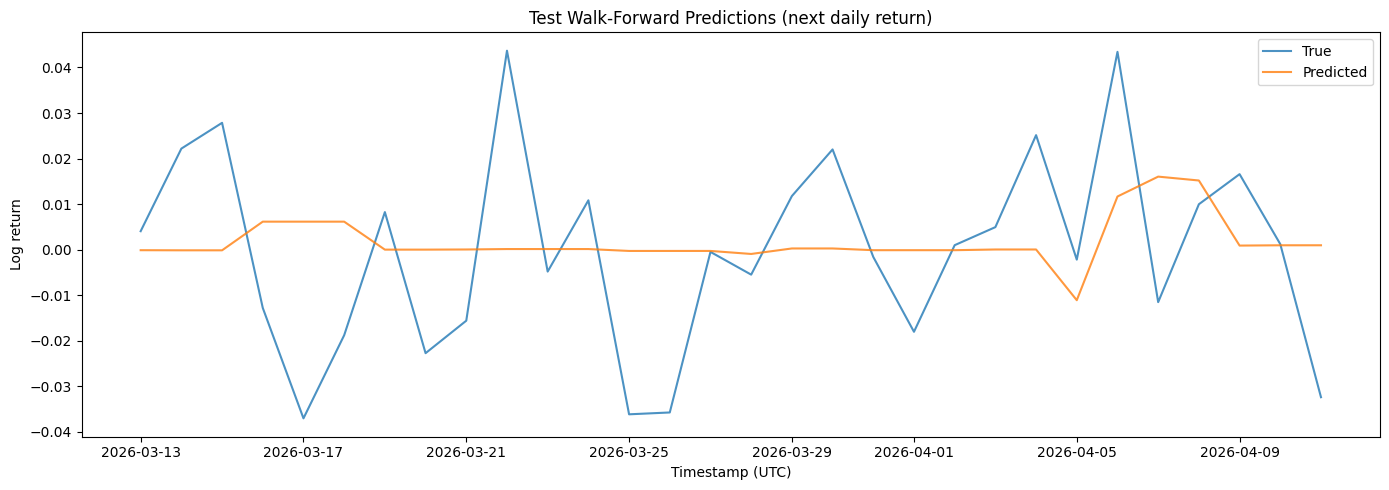

{'val_rmse_mean': 0.023405397883072658,
 'val_mae_mean': 0.020292830653488636,
 'test_rmse_mean': 0.020967080762229563,
 'test_mae_mean': 0.017668055184185506,
 'best_params': {'seq_len': 10,
  'lstm_units': 32,
  'dropout': 0.2,
  'learning_rate': 0.0005,
  'batch_size': 8}}

In [8]:
# Quick diagnostics
plt.figure(figsize=(14, 5))
plot_df = test_preds_df.copy()
plot_df[TIMESTAMP_COL] = pd.to_datetime(plot_df[TIMESTAMP_COL], utc=True)
plot_df = plot_df.sort_values(TIMESTAMP_COL)

plt.plot(plot_df[TIMESTAMP_COL], plot_df['y_true'], label='True', alpha=0.8)
plt.plot(plot_df[TIMESTAMP_COL], plot_df['y_pred'], label='Predicted', alpha=0.8)
plt.title('Test Walk-Forward Predictions (next daily return)')
plt.xlabel('Timestamp (UTC)')
plt.ylabel('Log return')
plt.legend()
plt.tight_layout()
plt.show()

summary = {
    'val_rmse_mean': float(val_metrics_df['rmse'].mean()),
    'val_mae_mean': float(val_metrics_df['mae'].mean()),
    'test_rmse_mean': float(test_metrics_df['rmse'].mean()),
    'test_mae_mean': float(test_metrics_df['mae'].mean()),
    'best_params': best_params,
}

with (ARTIFACTS_DIR / 'summary.json').open('w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2)

summary



## Notes

- The notebook saves intermediate and best artifacts into `artifacts/lstm_walk_forward/`.
- Target variable is daily return `r_t = log(P_t / P_{t-1})`, predicted one day ahead.
- `ModelCheckpoint` + `BackupAndRestore` keep progress safe if training is interrupted.
- TensorBoard starts automatically at training time on `http://127.0.0.1:6006` (if `AUTO_START_TENSORBOARD=True`) when the `tensorboard` package is installed, and logs to `artifacts/lstm_walk_forward/tensorboard/`.
- For CUDA speedups, this notebook auto-detects GPUs, enables memory growth, XLA, and mixed precision.
- If CUDA is required, set `REQUIRE_CUDA = True` in the config cell to fail fast when no GPU is available.
- To make training faster/slower, adjust `GRID_LIMIT`, `FOLD_STEP_DAYS`, and `MAX_EPOCHS`.

